In [11]:
from typing import TypedDict , List

from langgraph.graph import StateGraph,START,END

In [12]:
class Agentstate(TypedDict):
    name:str
    age:int
    final:str

In [19]:
def firstnode(state:Agentstate)->Agentstate:    
    """this is the first node"""

    state["final"] = f"hi {state["name"]}"
    return state

def secondnode(state:Agentstate)->Agentstate:
    """this is the second node"""
    state["final"] = state["final"] +f"your age is {state["age"]}"
    return state

In [20]:
graph = StateGraph(Agentstate)

graph.add_node("firstnode",firstnode)
graph.add_node("secondnode",secondnode)

graph.add_edge(START,"firstnode")
graph.add_edge("firstnode","secondnode")
graph.add_edge("secondnode",END)

result_graph = graph.compile()

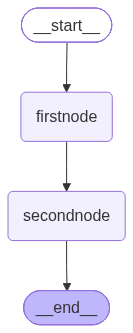

In [21]:
from IPython.display import Image
Image(result_graph.get_graph().draw_mermaid_png())

In [22]:
result_graph.invoke({"name":"tushar","age":20})

{'name': 'tushar', 'age': 20, 'final': 'hi tusharyour age is 20'}